<a href="https://colab.research.google.com/github/Shree1785/CSL701-CE49-Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Bhagyashree Shrikrishna Wagle CE3 CE49

Machine Learning Experiment No. 6

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


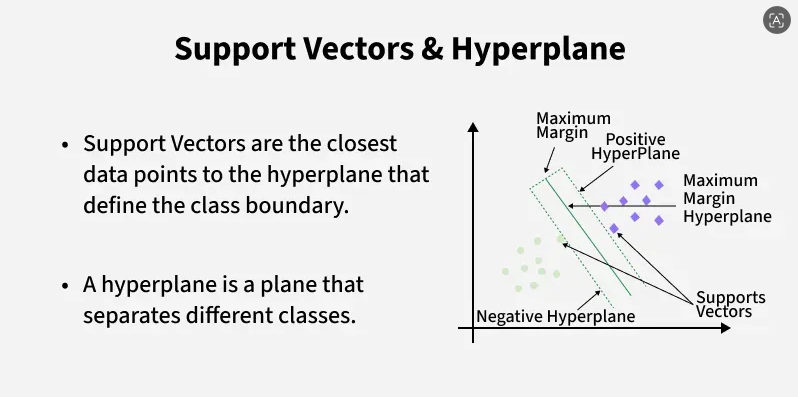
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv("Iris.csv")

# Display first 5 rows
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# Task 2: Explore the Dataset

In [ ]:
# Display dataset information
print("Shape of dataset:", df.shape)

print("\nDataset Information:")
df.info()

print("\nFirst 5 rows:")
display(df.head())

print("\nClass Distribution:")
print(df["Species"].value_counts())

print("\nStatistical Summary:")
display(df.describe())

Shape of dataset: (150, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

First 5 rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Class Distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Statistical Summary:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [ ]:
# Remove Id column
df = df.drop("Id", axis=1)

# Select features and target
X = df.drop("Species", axis=1)
y = df["Species"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
0            5.1           3.5            1.4           0.2
1            4.9           3.0            1.4           0.2
2            4.7           3.2            1.3           0.2
3            4.6           3.1            1.5           0.2
4            5.0           3.6            1.4           0.2

Target:
0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardize the features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data shape:", X_train_scaled.shape)
print("Testing data shape:", X_test_scaled.shape)

Training data shape: (120, 4)
Testing data shape: (30, 4)


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [ ]:
# Create Linear SVM model
svm_model = SVC(kernel="linear")

# Train the model
svm_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_svm = svm_model.predict(X_test_scaled)

print("SVM Predictions:")
print(y_pred_svm)

SVM Predictions:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


In [ ]:
# Calculate Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_accuracy)
print("SVM Accuracy (%):", svm_accuracy * 100)

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("\nSVM Confusion Matrix:")
print(cm_svm)

# Classification Report
print("\nSVM Classification Report:")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 1.0
SVM Accuracy (%): 100.0

SVM Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]

SVM Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

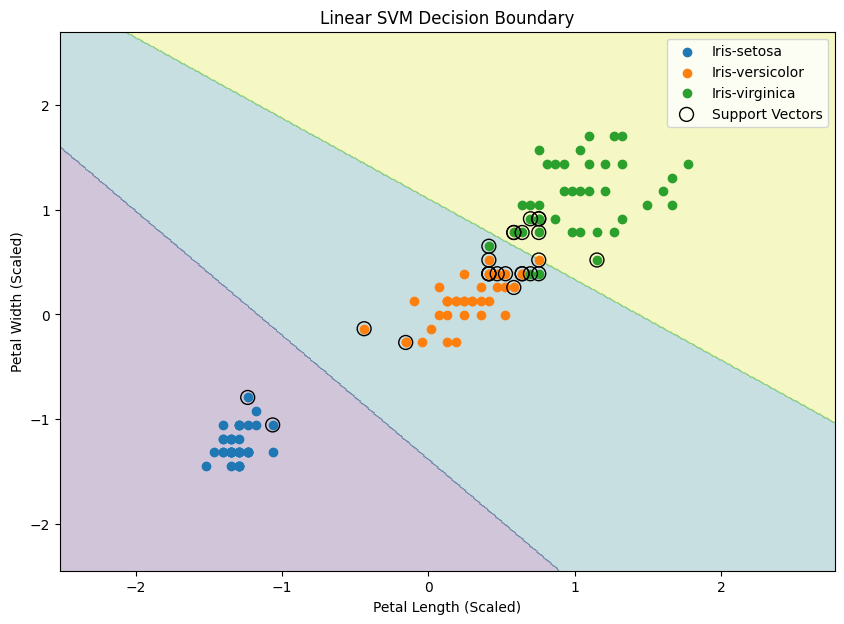

In [ ]:
# Select Petal Length and Petal Width
X_2d = df[["PetalLengthCm", "PetalWidthCm"]]
y_2d = df["Species"]

# Split the 2-D data
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    y_2d,
    test_size=0.2,
    random_state=42,
    stratify=y_2d
)

# Scale the data
scaler_2d = StandardScaler()

X_train_2d_scaled = scaler_2d.fit_transform(X_train_2d)
X_test_2d_scaled = scaler_2d.transform(X_test_2d)

# Train Linear SVM
svm_2d = SVC(kernel="linear")
svm_2d.fit(X_train_2d_scaled, y_train_2d)

# Create mesh grid
x_min = X_train_2d_scaled[:, 0].min() - 1
x_max = X_train_2d_scaled[:, 0].max() + 1

y_min = X_train_2d_scaled[:, 1].min() - 1
y_max = X_train_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Predict for every point in the grid
Z = svm_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Convert class labels to numbers for plotting
class_names = sorted(y_2d.unique())
class_to_num = {name: i for i, name in enumerate(class_names)}

Z_num = np.vectorize(class_to_num.get)(Z)
y_num = np.array([class_to_num[label] for label in y_train_2d])

# Plot decision boundary
plt.figure(figsize=(10, 7))

plt.contourf(xx, yy, Z_num, alpha=0.25)

for i, class_name in enumerate(class_names):
    mask = y_num == i
    plt.scatter(
        X_train_2d_scaled[mask, 0],
        X_train_2d_scaled[mask, 1],
        label=class_name
    )

# Plot support vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="black",
    label="Support Vectors"
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Linear SVM Decision Boundary")
plt.legend()
plt.show()

# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

In [ ]:
# Train Logistic Regression model
logistic_model = LogisticRegression(max_iter=200)

logistic_model.fit(X_train_2d_scaled, y_train_2d)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test_2d_scaled)

print("Logistic Regression Predictions:")
print(y_pred_logistic)

Logistic Regression Predictions:
['Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-setosa' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-virginica' 'Iris-versicolor' 'Iris-virginica' 'Iris-virginica'
 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa' 'Iris-setosa'
 'Iris-setosa' 'Iris-versicolor' 'Iris-versicolor' 'Iris-virginica'
 'Iris-setosa' 'Iris-virginica' 'Iris-versicolor' 'Iris-versicolor'
 'Iris-virginica' 'Iris-virginica' 'Iris-versicolor' 'Iris-setosa'
 'Iris-virginica' 'Iris-setosa']


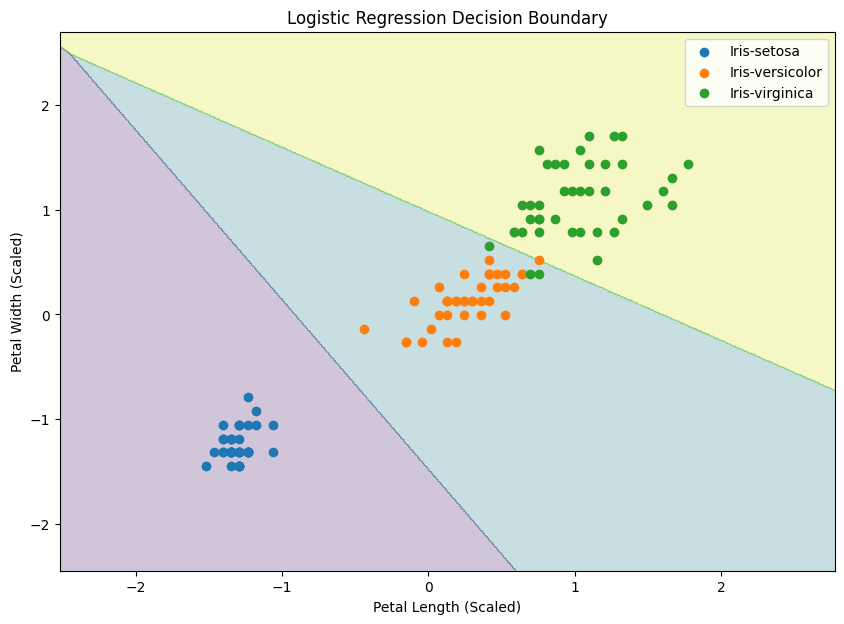

In [ ]:
# Predict classes for the mesh grid
Z_logistic = logistic_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z_logistic = Z_logistic.reshape(xx.shape)

# Convert class names to numbers
Z_logistic_num = np.vectorize(class_to_num.get)(Z_logistic)

# Plot decision boundary
plt.figure(figsize=(10, 7))

plt.contourf(
    xx,
    yy,
    Z_logistic_num,
    alpha=0.25
)

# Plot training data
for i, class_name in enumerate(class_names):
    mask = y_num == i

    plt.scatter(
        X_train_2d_scaled[mask, 0],
        X_train_2d_scaled[mask, 1],
        label=class_name
    )

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

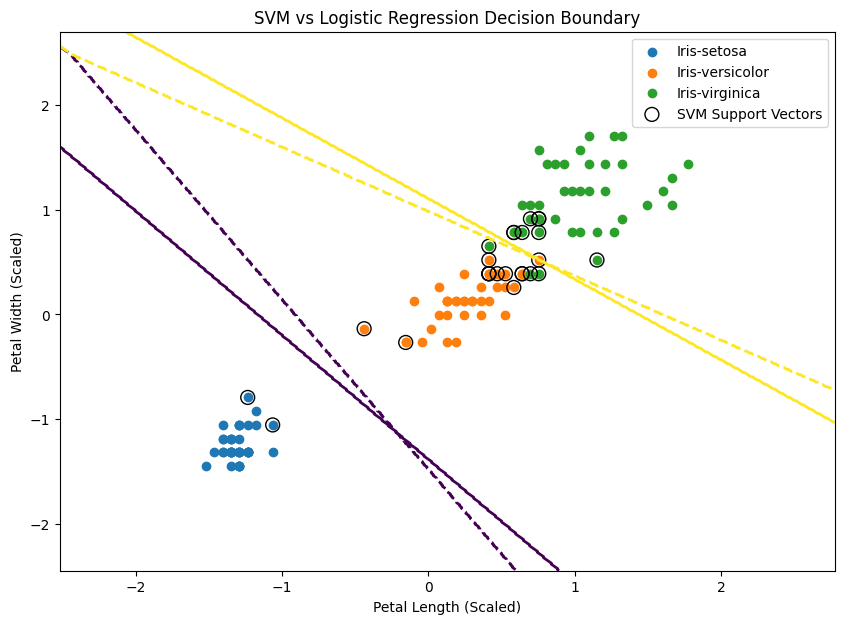

In [ ]:
plt.figure(figsize=(10, 7))

# SVM boundary
plt.contour(
    xx,
    yy,
    Z_num,
    levels=np.arange(len(class_names) - 1) + 0.5,
    linewidths=2
)

# Logistic Regression boundary
plt.contour(
    xx,
    yy,
    Z_logistic_num,
    levels=np.arange(len(class_names) - 1) + 0.5,
    linestyles="--",
    linewidths=2
)

# Plot data points
for i, class_name in enumerate(class_names):
    mask = y_num == i

    plt.scatter(
        X_train_2d_scaled[mask, 0],
        X_train_2d_scaled[mask, 1],
        label=class_name
    )

# Plot SVM support vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=100,
    facecolors="none",
    edgecolors="black",
    label="SVM Support Vectors"
)

plt.xlabel("Petal Length (Scaled)")
plt.ylabel("Petal Width (Scaled)")
plt.title("SVM vs Logistic Regression Decision Boundary")
plt.legend()
plt.show()

# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [ ]:
# Logistic Regression accuracy
logistic_accuracy = accuracy_score(y_test_2d, y_pred_logistic)

print("Linear SVM Accuracy:", svm_2d.score(X_test_2d_scaled, y_test_2d))
print("Logistic Regression Accuracy:", logistic_accuracy)

print("\n" + "="*50)
print("SVM Confusion Matrix")
print("="*50)

print(confusion_matrix(y_test_2d, svm_2d.predict(X_test_2d_scaled)))

print("\nSVM Classification Report")
print("="*50)

print(classification_report(
    y_test_2d,
    svm_2d.predict(X_test_2d_scaled)
))

print("\n" + "="*50)
print("Logistic Regression Confusion Matrix")
print("="*50)

print(confusion_matrix(y_test_2d, y_pred_logistic))

print("\nLogistic Regression Classification Report")
print("="*50)

print(classification_report(
    y_test_2d,
    y_pred_logistic
))

Linear SVM Accuracy: 0.9333333333333333
Logistic Regression Accuracy: 0.9333333333333333

SVM Confusion Matrix
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

SVM Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30


Logistic Regression Confusion Matrix
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Logistic Regression Classification Report
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg   

# Conclusion

The experiment successfully demonstrated the implementation of Support Vector Machine (SVM) for classification using the Iris dataset. The dataset was preprocessed and standardized before training the model. A Linear SVM was implemented and its decision boundary and support vectors were visualized. Logistic Regression was also implemented as a normal linear classifier for comparison. The performance of both classifiers was evaluated using accuracy, confusion matrix, and classification report. Thus, the experiment helped in understanding SVM classification, decision boundaries, support vectors, and comparison with a linear classification method.